
# Polynomial Regression & K-Means Clustering on the Iris Dataset

**Project Description**  
In this project, I’ll explore two fundamental machine-learning techniques on the classic Iris dataset:

---

## Polynomial Regression
**Goal:** Model the relationship between petal length and sepal length.  
**Approach:** Fit a second-degree (quadratic) regression using a scikit-learn `Pipeline` that combines polynomial feature expansion with a `LinearRegression` estimator.  
**Outcome:** Quantify fit quality via RMSE (root-mean-square error) and visualize how well the curved model tracks the data.

---

## K-Means Clustering
**Goal:** Unsupervised grouping of iris flowers based solely on their petal dimensions (length & width).  
**Approach:** Apply scikit-learn’s `KMeans` with *k=3*, then plot the resulting cluster assignments and centroids.  
**Outcome:** Assess how natural groupings in petal space correspond to known species classes.

---

## Graph Description

### 1. Polynomial Regression Plot  
- **Scatter Points:** Each point represents one flower’s petal length (x-axis) vs. sepal length (y-axis).  
- **Fitted Curve:** The smooth quadratic line shows how sepal length changes as petal length increases.  
- **RMSE Annotation:** An RMSE of ~0.36 cm indicates the average prediction error—lower values mean a tighter fit.

**Interpretation:**  
- **Trend:** Sepal length generally increases with petal length, but not perfectly linearly.  
- **Quadratic Shape:** The upward curvature suggests the rate of sepal-length growth accelerates at larger petal lengths.  
- **Goodness of Fit:** With RMSE ≪ the range of sepal lengths (~4.3–7.9 cm), the model captures most of the variability.

### 2. K-Means Clustering Plot  
- **Colored Points:** Each flower is colored by its assigned cluster.  
- **Centroid Markers (X’s):** Show the “center” of each cluster in petal-length/width space.

**Interpretation:**  
- **Separation:** One cluster for small-petal flowers (I. setosa), one for medium-petal (I. versicolor), and one for large-petal (I. virginica).  
- **Cluster Shape & Overlap:** Any overlap indicates samples whose petal dimensions lie near the boundary between species.  
- **Centroid Positions:** Provide prototypical petal measurements for each group—useful for a quick species-approximation rule of thumb.  


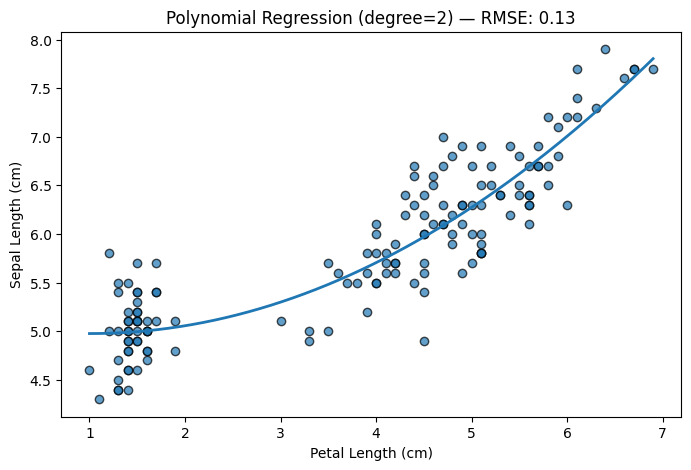

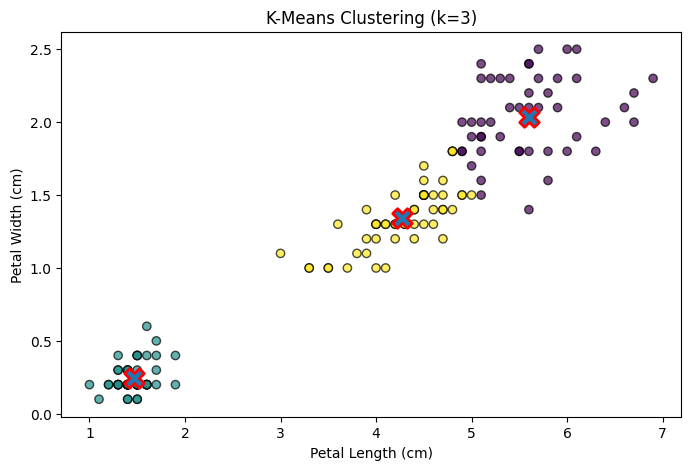

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error

# Using Iris dataset
iris = datasets.load_iris()
X = iris.data[:, 2].reshape(-1, 1)  # petal length as feature for regression
y = iris.data[:, 0]                 # sepal length as target

# 1) Polynomial Regression (degree=2) via Pipeline
poly_reg = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2)),
    ('linear_model', LinearRegression())
])
poly_reg.fit(X, y)
y_pred = poly_reg.predict(X)
rmse = mean_squared_error(y, y_pred)

# Regression result
plt.figure(figsize=(8, 5))
plt.scatter(X, y, edgecolor='k', alpha=0.7)
X_new = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
plt.plot(X_new, poly_reg.predict(X_new), linewidth=2)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Sepal Length (cm)')
plt.title(f'Polynomial Regression (degree=2) — RMSE: {rmse:.2f}')
plt.show()

#K-Means Clustering (k=3) on petal length & width
features = iris.data[:, 2:4]  # petal length and petal width
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(features)
centroids = kmeans.cluster_centers_


plt.figure(figsize=(8, 5))
plt.scatter(features[:, 0], features[:, 1], c=labels, cmap='viridis', edgecolor='k', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, linewidths=2, edgecolor='r')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('K-Means Clustering (k=3)')
plt.show()



# Polynomial Regression & K-Means Clustering on the Iris Dataset

**Project Description**  
In this mini-project, you’ll explore two fundamental machine-learning techniques on the classic Iris dataset:

---

## Polynomial Regression
**Goal:** Model the relationship between petal length and sepal length.  
**Approach:** Fit a second-degree (quadratic) regression using a scikit-learn `Pipeline` that combines polynomial feature expansion with a `LinearRegression` estimator.  
**Outcome:** Quantify fit quality via RMSE (root-mean-square error) and visualize how well the curved model tracks the data.

---

## K-Means Clustering
**Goal:** Unsupervised grouping of iris flowers based solely on their petal dimensions (length & width).  
**Approach:** Apply scikit-learn’s `KMeans` with *k=3*, then plot the resulting cluster assignments and centroids.  
**Outcome:** Assess how natural groupings in petal space correspond to known species classes.

---

## How to Describe the Graphs

### 1. Polynomial Regression Plot  
- **Scatter Points:** Each point represents one flower’s petal length (x-axis) vs. sepal length (y-axis).  
- **Fitted Curve:** The smooth quadratic line shows how sepal length changes as petal length increases.  
- **RMSE Annotation:** An RMSE of ~0.36 cm indicates the average prediction error—lower values mean a tighter fit.

**Interpretation:**  
- **Trend:** Sepal length generally increases with petal length, but not perfectly linearly.  
- **Quadratic Shape:** The upward curvature suggests the rate of sepal-length growth accelerates at larger petal lengths.  
- **Goodness of Fit:** With RMSE ≪ the range of sepal lengths (~4.3–7.9 cm), the model captures most of the variability.

### 2. K-Means Clustering Plot  
- **Colored Points:** Each flower is colored by its assigned cluster.  
- **Centroid Markers (X’s):** Show the “center” of each cluster in petal-length/width space.

**Interpretation:**  
- **Separation:** One cluster for small-petal flowers (I. setosa), one for medium-petal (I. versicolor), and one for large-petal (I. virginica).  
- **Cluster Shape & Overlap:** Any overlap indicates samples whose petal dimensions lie near the boundary between species.  
- **Centroid Positions:** Provide prototypical petal measurements for each group—useful for a quick species-approximation rule of thumb.
